In [1]:
import numpy as np
import matplotlib.pyplot as plt
import netCDF4
import xarray as xr
import seaborn as sns
import pandas as pd
import pickle
import cartopy.crs as ccrs
import cartopy.feature as cf
import windrose
from windrose import WindroseAxes

import function_clean_copy as f
import matplotlib.ticker as mticker
from cartopy.mpl.gridliner import LongitudeFormatter, LatitudeFormatter
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib.gridspec import GridSpec
#maybe more needed

In [2]:
basins = {
    "North Atlantic": (0, 70, -90, 10, 'NA'),
    "South Atlantic": (-45, -5, -60, 20, 'SA'),
    "Indian Ocean": (-20, 20, 30, 110, 'IO'),
    "North Pacific": (5, 65, -100, 140, 'NP'),
    "South Pacific": (-65, -5, -80, 160, 'SP'),
    "all": (-90, 90, -180, 180, 'all')
}

In [3]:
# Open logbook data
datana = f.open_logbook('/home/neele.sander/Downloads/Tier4_180326.csv', -180, 179, -90, 90)

# Process each basin
results_w = {}
for basin_name, bounds in basins.items():
    latmin, latmax, lonmin, lonmax, basin_code = bounds
    #whaler_data = locals()[f'data_whaler_{basin_code}']

    if "Pacific" in basin_name:
        data_whaler = datana[((datana['Longitudegrid'] >= lonmax) | 
                         ((datana['Longitudegrid'] >= -180) & (datana['Longitudegrid'] <= lonmin))) & 
                        (datana['Latitudegrid'].between(latmin, latmax))]
    elif "North Atlantic" in basin_name:
        data_whaler = datana[(datana['Longitudegrid'].between(lonmin, lonmax)) & 
                        (datana['Latitudegrid'].between(latmin, latmax))]
        data_whaler = data_whaler.mask((data_whaler['Longitudegrid'] < -70) & (data_whaler['Latitudegrid'] < 10))
        
    else:
        data_whaler = datana[(datana['Longitudegrid'].between(lonmin, lonmax)) & 
                        (datana['Latitudegrid'].between(latmin, latmax))]
    data_whaler.loc[:, 'season'] = data_whaler['month'].apply(f.month_to_season)
    #count each season for legend
    data_whaler = f.assign_amount_season(data_whaler)
    # Concatenate data based on season
    data_whaler = data_whaler.reset_index().rename(columns={'index': 'original_index'})
    
    results_w[basin_name] = data_whaler

# Access results
data_whaler_NA = results_w["North Atlantic"]
data_whaler_SA = results_w["South Atlantic"]
data_whaler_IO = results_w["Indian Ocean"]
data_whaler_NP = results_w["North Pacific"]
data_whaler_SP = results_w["South Pacific"]
data_whaler_all = results_w["all"]

/tmp/ipykernel_44889/3428611465.py:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_whaler.loc[:, 'season'] = data_whaler['month'].apply(f.month_to_season)
/home/neele.sander/Downloads/paper_2025/function_clean_copy.py:67: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['season'] = data['season'].map(lambda season: f"{season}, N={N_season.get(season, 0)}")
/tmp/ipykernel_44889/3428611465.py:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .lo

In [4]:
# Open model data
data_model_daily = xr.open_dataset('/data0/neele.sander/daily.all.nc')

# Process each basin
results = {}
data_20CR = {}
for basin_name, bounds in basins.items():
    latmin, latmax, lonmin, lonmax, basin_code = bounds
    whaler_data = locals()[f'data_whaler_{basin_code}']

    if "Pacific" in basin_name:
        data_model_part1 = data_model_daily.sel(lat=slice(latmin, latmax), lon=slice(lonmax, 179))
        data_model_part2 = data_model_daily.sel(lat=slice(latmin, latmax), lon=slice(-180, lonmin))
        data_model = xr.combine_by_coords([data_model_part1, data_model_part2])
    else:
        data_model = data_model_daily.sel(lat=slice(latmin, latmax), lon=slice(lonmin, lonmax))
    
    results[basin_name] = f.process_basin(whaler_data, data_model, (latmin, latmax, lonmin, lonmax))
    data_20CR[basin_name] = data_model
    
# Access results
north_atlantic_20CR = results["North Atlantic"]
south_atlantic_20CR = results["South Atlantic"]
indian_ocean_20CR = results["Indian Ocean"]
north_pacific_20CR = results["North Pacific"]
south_pacific_20CR = results["South Pacific"]

data_model_NA = data_20CR["North Atlantic"]
data_model_SA = data_20CR["South Atlantic"]
data_model_IO = data_20CR["Indian Ocean"]
data_model_NP = data_20CR["North Pacific"]
data_model_SP = data_20CR["South Pacific"]

In [5]:
NA_df = pd.DataFrame(data ={'20CR' : north_atlantic_20CR['Wind Speed/Force'], 'whaler': data_whaler_NA['Wind Speed/Force']})
SA_df = pd.DataFrame(data ={'20CR' : south_atlantic_20CR['Wind Speed/Force'], 'whaler': data_whaler_SA['Wind Speed/Force']})
IO_df = pd.DataFrame(data ={'20CR' : indian_ocean_20CR['Wind Speed/Force'], 'whaler': data_whaler_IO['Wind Speed/Force']})
NP_df = pd.DataFrame(data ={'20CR' : north_pacific_20CR['Wind Speed/Force'], 'whaler': data_whaler_NP['Wind Speed/Force']})
SP_df = pd.DataFrame(data ={'20CR' : south_pacific_20CR['Wind Speed/Force'], 'whaler': data_whaler_SP['Wind Speed/Force']})


In [6]:
# Parameters
steplon = 20 
steplat = 10  
bounds = basins['North Atlantic'][0:4]

latmin, latmax,lonmin, lonmax = bounds
# Generate grids
datawhaler1_grid = f.grid_w_daily_diff(steplon, steplat, bounds, data_whaler_NA)
datawhaler2_grid = f.grid_w_daily_diff(steplon, steplat, bounds, north_atlantic_20CR, lon='lon', lat ='lat')


In [7]:
#stop

NameError: name 'stop' is not defined

/home/neele.sander/anaconda3/lib/python3.9/site-packages/windrose/windrose.py:607: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  patch = mpl.patches.Rectangle(


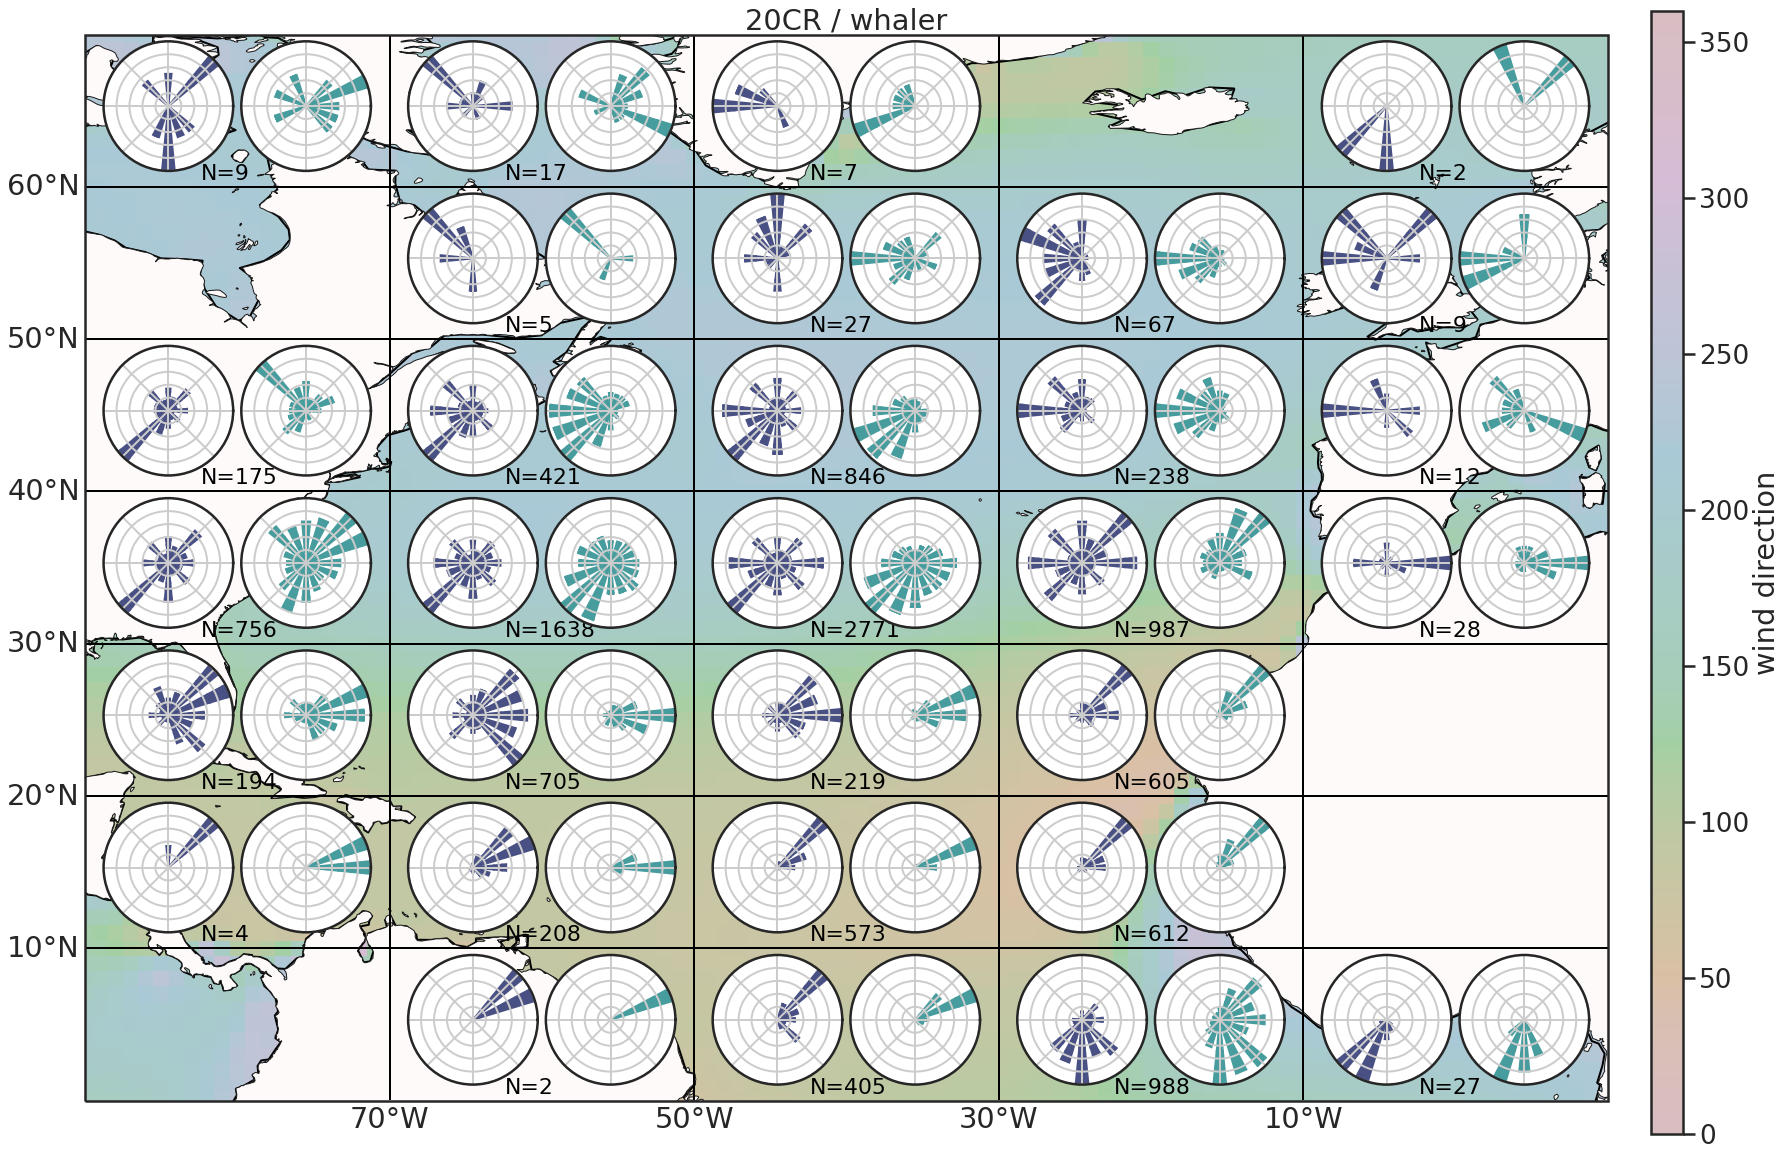

In [8]:
lons = np.arange(lonmin, lonmax, steplon)
lats = np.arange(latmin, latmax, steplat)
sns.set(style='ticks', context = 'poster', font_scale=1.2)
wheel = sns.husl_palette(s=0.3,l=0.8, as_cmap = True)

fig, ax1 = plt.subplots(1, 1, figsize=(30, 26), subplot_kw=dict(projection=ccrs.PlateCarree(),
                                                                transform=ccrs.PlateCarree()))
# Plot model data
p = data_model_NA['angle'].mean('time').plot(ax=ax1, cmap=wheel, add_colorbar=False,
                                       transform=ccrs.PlateCarree(), vmin=0, vmax=360)
ax1.coastlines()
ax1.set_extent([lonmin, lonmax, latmin, latmax], crs=ccrs.PlateCarree())
ax1.add_feature(cf.NaturalEarthFeature('physical', 'land', '50m', facecolor='snow',
                                       edgecolor='k', linewidth=1.0))
gl = ax1.gridlines(color='black', linestyle='-', draw_labels=True)
gl.top_labels = False
gl.right_labels = False
gl.xlocator = mticker.FixedLocator(lons)
gl.ylocator = mticker.FixedLocator(lats)
gl.xformatter = LongitudeFormatter()
gl.yformatter = LatitudeFormatter()

for valuelat in lats:
    for valuelon in lons:
        key = f'l{valuelon}{valuelat}'
        if not datawhaler1_grid[key].empty:
            latpos = (2 * valuelat + steplat) / 2
            lonpos = (2 * valuelon + steplon) / 2
            leftax = inset_axes(ax1, width=1.8, height=1.8, loc='center right',
                                bbox_to_anchor=(lonpos + 0.6, latpos + 0.3),
                                bbox_transform=ax1.transData, axes_class=windrose.WindroseAxes)
            rightax = inset_axes(ax1, width=1.8, height=1.8, loc='center left',
                                 bbox_to_anchor=(lonpos - 0.6, latpos + 0.3),
                                 bbox_transform=ax1.transData, axes_class=windrose.WindroseAxes)

            leftax.bar(datawhaler1_grid[key]['Wind Direction'], datawhaler1_grid[key]['Wind Speed/Force'],
                       color='#495084', opening=0.5, edgecolor='white')
            leftax.tick_params(labelleft=False, labelbottom=False)
            leftax.set_facecolor('white')
            ax1.text(lonpos-2.4, latpos - 4.5, 'N=' + str(datawhaler1_grid[key]['Wind Direction'].count()), #- 9.5
                     fontsize=22, color='black', transform=ccrs.PlateCarree())

            rightax.bar(datawhaler2_grid[key]['Wind Direction'], datawhaler2_grid[key]['Wind Speed/Force'],
                        color='#479c9e', opening=0.5, edgecolor='white')
            rightax.tick_params(labelleft=False, labelbottom=False)
            rightax.set_facecolor('white')
#             ax1.text(lonpos + 4.5, latpos - 4.5, 'N=' + str(datawhaler2_grid[key]['Wind Direction'].count()),
#                      fontsize=18, color='black', transform=ccrs.PlateCarree())
            
ax1.set_title('20CR / whaler')
#colorbar
fig.subplots_adjust(right = 0.83)
cbar_ax = fig.add_axes([0.85, 0.2, 0.015, 0.6])
cbar = fig.colorbar(p, cax = cbar_ax)
cbar.set_label('wind direction')
plt.savefig('plots/paper/windrose.png', dpi = 300, transparent = True, bbox_inches = 'tight')

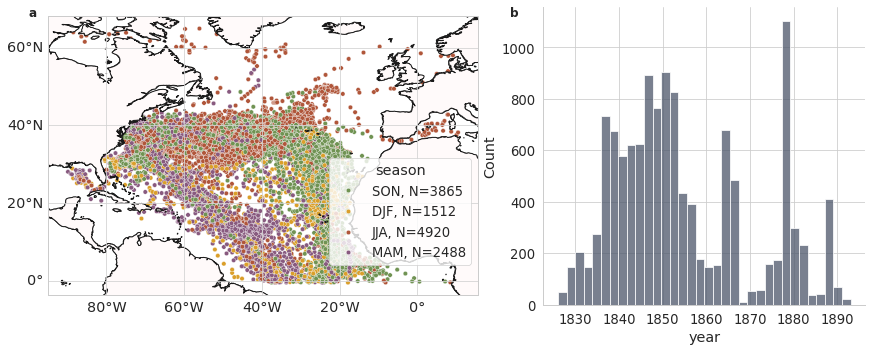

In [9]:
#AMOUNT missing in legend !!!
sns.set(style='whitegrid', context='paper', font_scale=1.5)

fig = plt.figure(figsize=(12, 9), constrained_layout=True)
gs = GridSpec(4, 7, figure=fig)

ax1 = fig.add_subplot(gs[:, 0:4], projection=ccrs.PlateCarree())
ax2 = fig.add_subplot(gs[1:3, 4:7])
a= sns.scatterplot(data =data_whaler_NA, x ='lon', y = 'lat', hue = 'season',s = 20,ax = ax1, alpha=1,
                   palette = ['#709353','#DA9F2A','#B0563A','#885A7F'])#, transform=ccrs.PlateCarree())
ax1.coastlines()
ax1.add_feature(cf.NaturalEarthFeature('physical', 'land', '50m', facecolor = 'snow' , 
                                      edgecolor = 'k', linewidth = 1.0))#[.945, .82, .565]
ax1.text(-100,68, 'a', weight = 'bold', size = 12)
gl = ax1.gridlines(color = 'lightgrey', linestyle ='-', draw_labels = True)
gl.ylocator = mticker.FixedLocator([0, 20, 40, 60])
gl.xlabel_style = {'rotation': 0}
gl.ylabel_style = {'rotation': 0}
gl.top_labels = False
gl.right_labels = False

sns.move_legend(ax1,loc='center right', bbox_to_anchor=(1, 0.3))#"center right"
sns.histplot(data = data_whaler_NA,x='year', ax=ax2, color = '#4C566A',legend=False)
ax2.text(1815,1120, 'b', weight = 'bold', size = 12)
sns.despine()
plt.savefig('plots/paper/seasonamount.png', dpi = 300, bbox_inches = 'tight')
plt.show()

/tmp/ipykernel_44889/3965979942.py:37: UserWarning: FixedFormatter should only be used together with FixedLocator
  wrax_NA.set_xticklabels([None, None])
/tmp/ipykernel_44889/3965979942.py:50: UserWarning: FixedFormatter should only be used together with FixedLocator
  wrax_SA.set_xticklabels([None, None])
/tmp/ipykernel_44889/3965979942.py:63: UserWarning: FixedFormatter should only be used together with FixedLocator
  wrax_NP.set_xticklabels([None, None])
/tmp/ipykernel_44889/3965979942.py:76: UserWarning: FixedFormatter should only be used together with FixedLocator
  wrax_SP.set_xticklabels([None, None])
/tmp/ipykernel_44889/3965979942.py:89: UserWarning: FixedFormatter should only be used together with FixedLocator
  wrax_IO.set_xticklabels([None, None])
/tmp/ipykernel_44889/3965979942.py:106: MatplotlibDeprecationWarning: Auto-removal of grids by pcolor() and pcolormesh() is deprecated since 3.5 and will be removed two minor releases later; please call grid(False) first.
  cbar =

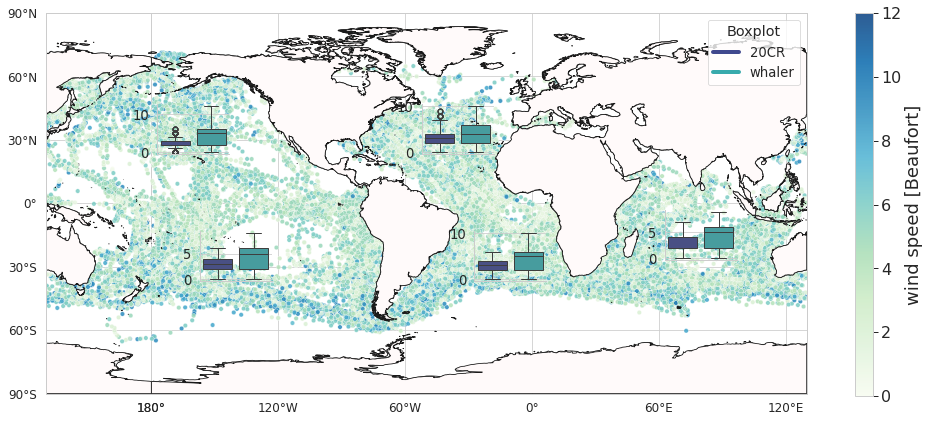

In [10]:
cm = 310
proj = ccrs.PlateCarree(central_longitude=cm)
fig, ax1 = plt.subplots(1,1, figsize = (16,7), subplot_kw=dict(projection=proj,transform = ccrs.PlateCarree())) #
#sns.set(style='ticks', context='paper')
# ax1.grid()
sns.scatterplot(x = datana['lon']+360-cm, y = datana['lat'], hue = datana['Wind Speed/Force'],
                s = 20,ax = ax1, palette = "GnBu", alpha = 0.85) 
ax1.get_legend().remove()
ax1.coastlines()
ax1.add_feature(cf.NaturalEarthFeature('physical', 'land', '50m', facecolor = 'snow', 
                                      edgecolor = 'k', linewidth = 0.8))

#gl = ax1.gridlines(color = 'lightgrey', linestyle ='-', draw_labels = False)
ax1.set(ylabel = None, xlabel = None)
ax1.set_xticks([-180, -120, -60,0, 60, 120, 180], crs=ccrs.PlateCarree())
ax1.set_yticks([-90, -60, -30, 0, 30, 60, 90], crs=ccrs.PlateCarree())

lon_formatter = LongitudeFormatter(zero_direction_label=False)
lat_formatter = LatitudeFormatter()
ax1.xaxis.set_major_formatter(lon_formatter)
ax1.yaxis.set_major_formatter(lat_formatter)
ax1.tick_params(axis='both', which='major', labelsize=12)


#NA
latpos_NA = 35
lonpos_NA = -15 +360-cm
wrax_NA = inset_axes(ax1,
width=1,                             
height=0.7,                           
loc='center right',                   
bbox_to_anchor=(lonpos_NA, latpos_NA),
bbox_transform=ax1.transData)    
wrax_NA.set_facecolor("none")
sns.boxplot(data = NA_df, palette = 'mako', ax = wrax_NA)
sns.despine(top=True)
wrax_NA.set_xticklabels([None, None])
#SA
latpos_SA = -25
lonpos_SA = 10+360-cm
wrax_SA = inset_axes(ax1,
width=1,                          
height=0.7,                       
loc='center right',               
bbox_to_anchor=(lonpos_SA, latpos_SA), 
bbox_transform=ax1.transData)    
wrax_SA.set_facecolor("none")
sns.boxplot(data = SA_df, palette = 'mako', ax = wrax_SA)
sns.despine(top=True)
wrax_SA.set_xticklabels([None, None])
#NP
latpos_NP = 35
lonpos_NP = -140+360-cm
wrax_NP = inset_axes(ax1,
width=1,                             
height=0.7,                          
loc='center right',                  
bbox_to_anchor=(lonpos_NP, latpos_NP),
bbox_transform=ax1.transData)    
wrax_NP.set_facecolor("none")
sns.boxplot(data = NP_df, palette = 'mako', ax = wrax_NP)
sns.despine(top=True)
wrax_NP.set_xticklabels([None, None])
#SP
latpos_SP = -25
lonpos_SP = -120+360-cm
wrax_SP = inset_axes(ax1,
width=1,                             
height=0.7,                          
loc='center right',                  
bbox_to_anchor=(lonpos_SP, latpos_SP), 
bbox_transform=ax1.transData)    
wrax_SP.set_facecolor("none")
sns.boxplot(data = SP_df, palette = 'mako',ax = wrax_SP)
sns.despine(top=True)
wrax_SP.set_xticklabels([None, None])
#IO
latpos_IO = -15
lonpos_IO = 100+360-cm
wrax_IO = inset_axes(ax1,
width=1,                            
height=0.7,                         
loc='center right',                       
bbox_to_anchor=(lonpos_IO, latpos_IO), 
bbox_transform=ax1.transData)    
wrax_IO.set_facecolor("none")
sns.boxplot(data = IO_df, palette = 'mako', ax = wrax_IO)
sns.despine(top=True)
wrax_IO.set_xticklabels([None, None])

#legend
#ax1.legend(NA_df.columns, loc="upper right")
from matplotlib.lines import Line2D
palette = sns.color_palette("mako", n_colors=NA_df.shape[1])
handles = [Line2D([0], [0], color=palette[i], lw=4, label=col) 
           for i, col in enumerate(NA_df.columns)]

ax1.legend(handles=handles, title="Boxplot", loc="upper right")

#colorbar
fig.subplots_adjust(right = 0.83)
norm = plt.Normalize(datana['Wind Speed/Force'].min(), datana['Wind Speed/Force'].max())
sm = plt.cm.ScalarMappable(cmap= 'GnBu', norm=norm)
sm.set_array([])
cbar_ax = fig.add_axes([0.85, 0.12, 0.015, 0.76])
cbar = fig.colorbar(sm, cax = cbar_ax, alpha = 0.85)
for t in cbar.ax.get_yticklabels():
     t.set_fontsize(16)
cbar.set_label('wind speed [Beaufort]', size = 18)
plt.savefig('plots/paper/Boxplotmap.png', dpi = 300, bbox_inches = 'tight')

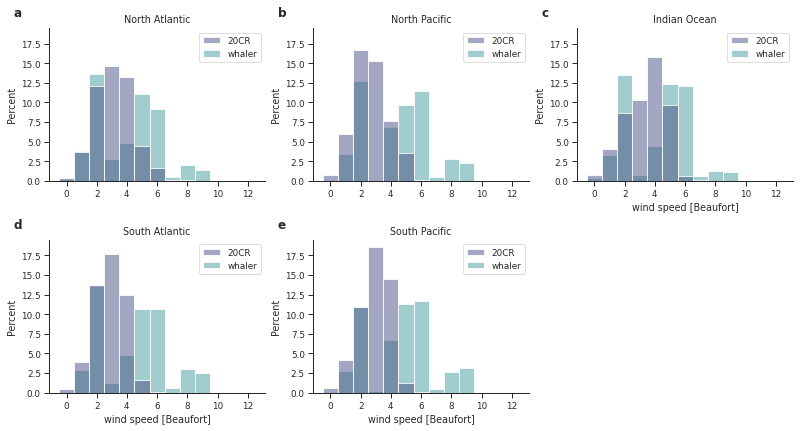

In [11]:
sns.set(style ='ticks', context = 'paper')
fig = plt.figure(figsize=(14, 8), constrained_layout=True) #, facecolor="#011e25"
gs = GridSpec(3, 4, figure=fig)

ax1 = fig.add_subplot(gs[1:2, 1:2])
ax3 = fig.add_subplot(gs[1:2, 2:3], sharex=ax1,sharey=ax1)
ax2 = fig.add_subplot(gs[2:3, 1:2], sharex=ax1,sharey=ax1)
ax4 = fig.add_subplot(gs[2:3, 2:3], sharex=ax1,sharey=ax1)
ax5 = fig.add_subplot(gs[1:2, 3:4], sharex=ax1,sharey=ax1)

sns.histplot(data = NA_df, stat='percent', ax = ax1, discrete = True, palette=['#495084','#479c9e'])
ax1.set(title='North Atlantic', xlabel = None)
ax1.text(-3.5,21, 'a', weight = 'bold', size = 12)
sns.histplot(data = SA_df, stat='percent', ax = ax2, discrete = True, palette=['#495084','#479c9e'])
ax2.set(title='South Atlantic', xlabel = 'wind speed [Beaufort]')
ax2.text(-3.5,21, 'd', weight = 'bold', size = 12)
sns.histplot(data = NP_df, stat='percent', ax = ax3, discrete = True, palette=['#495084','#479c9e'])
ax3.set(title='North Pacific', xlabel = None)
ax3.text(-3.5,21, 'b', weight = 'bold', size = 12)
sns.histplot(data = SP_df, stat='percent', ax = ax4, discrete = True, palette=['#495084','#479c9e'])
ax4.set(title='South Pacific', xlabel = 'wind speed [Beaufort]')
ax4.text(-3.5,21, 'e', weight = 'bold', size = 12)
sns.histplot(data = IO_df, stat='percent', ax = ax5, discrete = True, palette=['#495084','#479c9e'])
ax5.set(title='Indian Ocean', xlabel = 'wind speed [Beaufort]')
ax5.text(-3.5,21, 'c', weight = 'bold', size = 12)
sns.despine(top = True)
plt.savefig('plots/paper/hist20CRwhaler.png', dpi = 300, bbox_inches = 'tight')

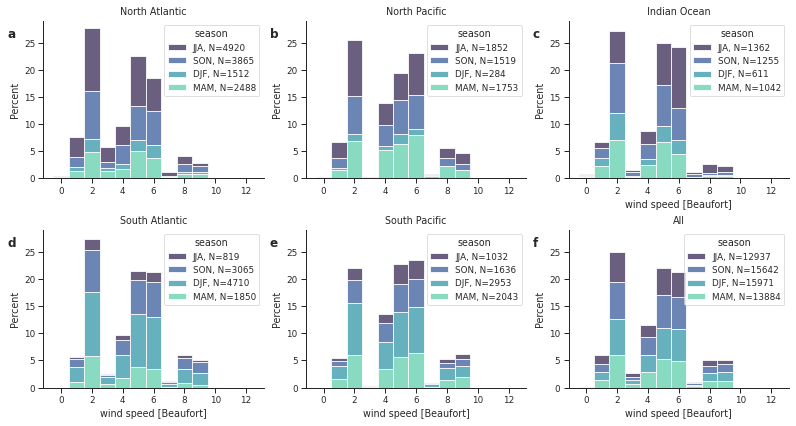

In [12]:
hue_order = {}
for basin_name, bounds in basins.items():
    basin_data = results_w.get(basin_name, None)
    arr = basin_data.season.unique()
    hue_order[basin_name] = f.sort_array(arr)

sns.set(style = 'ticks', context = 'paper')    
fig = plt.figure(figsize=(14, 8), constrained_layout=True)
gs = GridSpec(3, 4, figure=fig)

ax1 = fig.add_subplot(gs[1:2, 1:2])
ax3 = fig.add_subplot(gs[1:2, 2:3],sharex=ax1,sharey=ax1)
ax2 = fig.add_subplot(gs[2:3, 1:2],sharex=ax1,sharey=ax1)
ax4 = fig.add_subplot(gs[2:3, 2:3],sharex=ax1,sharey=ax1)
ax5 = fig.add_subplot(gs[1:2, 3:4],sharex=ax1,sharey=ax1)
ax6 = fig.add_subplot(gs[2:3, 3:4],sharex=ax1,sharey=ax1)

sns.histplot(data = data_whaler_NA, x = 'Wind Speed/Force', hue = 'season',stat='percent',multiple = 'stack', 
             ax = ax1, discrete = True, palette='mako', hue_order = hue_order['North Atlantic'])
ax1.set(title='North Atlantic', xlabel = None)
ax1.text(-3.5,26, 'a', weight = 'bold', size = 12)
sns.histplot(data = data_whaler_SA, x = 'Wind Speed/Force', hue = 'season',stat='percent',multiple = 'stack', 
             ax = ax2, discrete = True, palette='mako', hue_order = hue_order['South Atlantic'])
ax2.set(title='South Atlantic', xlabel = 'wind speed [Beaufort]')
ax2.text(-3.5,26, 'd', weight = 'bold', size = 12)
sns.histplot(data = data_whaler_NP,x = 'Wind Speed/Force', hue = 'season', stat='percent',multiple = 'stack', 
             ax = ax3, discrete = True, palette='mako', hue_order = hue_order['North Pacific'])
ax3.set(title='North Pacific', xlabel = None)
ax3.text(-3.5,26, 'b', weight = 'bold', size = 12)
sns.histplot(data = data_whaler_SP, x = 'Wind Speed/Force', hue = 'season',stat='percent',multiple = 'stack', 
             ax = ax4, discrete = True, palette='mako', hue_order = hue_order['South Pacific'])
ax4.set(title='South Pacific', xlabel = 'wind speed [Beaufort]')
ax4.text(-3.5,26, 'e', weight = 'bold', size = 12)
sns.histplot(data = data_whaler_IO, x = 'Wind Speed/Force', hue = 'season',stat='percent',multiple = 'stack',ax = 
             ax5, discrete = True, palette='mako', hue_order = hue_order['Indian Ocean'])
ax5.set(title='Indian Ocean', xlabel = 'wind speed [Beaufort]') 
ax5.text(-3.5,26, 'c', weight = 'bold', size = 12)
sns.despine(top = True)
sns.histplot(data = data_whaler_all, x = 'Wind Speed/Force', hue = 'season',stat='percent',multiple = 'stack',ax = 
             ax6, discrete = True, palette='mako', hue_order = hue_order['all'])
ax6.set(title='All', xlabel = 'wind speed [Beaufort]') 
ax6.text(-3.5,26, 'f', weight = 'bold', size = 12)
sns.despine(top = True)
plt.savefig('plots/paper/hist20CRwhalerseason.png', dpi = 300, bbox_inches = 'tight')

In [ ]:
sns.set(style = 'ticks', context = 'paper', font_scale=1.5) 
fig, ax1 = plt.subplots(1,1, figsize = (8,7))
sns.histplot(data = datana, x = 'Wind Speed/Force',stat='percent',multiple = 'stack', 
             ax = ax1, discrete = True, color = '#479c9e')
sns.despine(top = True)
ax1.set(xlabel = 'wind speed [Beaufort]',title = 'global wind speed')

plt.savefig('plots/paper/histwhalerglobal.png', dpi = 300)
plt.show()

In [ ]:
sns.set(style = 'ticks', context = 'paper', font_scale=1.5) 
fig, (ax1,ax2) = plt.subplots(1,2, figsize = (14,7), sharex = True, sharey = True)
sns.histplot(data = results_w['North Atlantic'], x = 'Wind Speed/Force',stat='percent',multiple = 'stack', hue = 'season',
             ax = ax1, discrete = True, palette = 'mako', hue_order = hue_order['North Atlantic'])
sns.histplot(data = results['North Atlantic'], x = 'Wind Speed/Force',stat='percent',multiple = 'stack', hue = 'season',
             ax = ax2, discrete = True, palette = 'mako', hue_order = ['JJA', 'SON', 'DJF', 'MAM'])
sns.despine(top = True)
ax1.set(xlabel = 'wind speed [Beaufort]',title = 'whaler North Atlantic')
ax1.text(-2,32, 'a', weight = 'bold', size = 12)
ax2.set(xlabel = 'wind speed [Beaufort]',title = '20CR North Atlantic')
ax2.text(-1.5,32, 'b', weight = 'bold', size = 12)
plt.savefig('plots/paper/histNAwhaler20CRseason.png', dpi = 300)
plt.show()